In [46]:
import pandas as pd
import numpy as np
from matplotlib import ticker
import matplotlib.pyplot as plt
from pathlib import Path

In [28]:
home = Path.home()
data_path = home / 'Programming/data/fraud-detection/data'
work_dir = home / (
    'Programming/Python/machine-learning-exercises/credit-card-fraud-detection'
    )
data_df = pd.read_csv(
    data_path / 'transactions_obf.csv', parse_dates=['transactionTime'],
    dtype={'availableCash': np.float64, 'transactionAmount': np.float64}
    )
data_df.sort_values(by='transactionTime', inplace=True)

In [29]:
# matplotlib style file
mplstyle_file = work_dir / 'barplot-style.mplstyle'
plt.style.use(mplstyle_file)

In [30]:
# turned some category types represented by integrals such as 'mcc'
# 'merchantCountry' and 'posEntryMode' to strings
category_list = [
    'eventId', 'accountNumber', 'merchantId', 'mcc',
    'merchantCountry', 'merchantZip', 'posEntryMode'
    ]
data_df[category_list] = data_df[category_list].astype('string')

In [31]:
labels_df = pd.read_csv(data_path / 'labels_obf.csv', parse_dates=['reportedTime'])
labels_df.sort_values(by='reportedTime', inplace=True)
data_df['fraudCase'] = data_df.eventId.isin(labels_df.eventId).astype(int)

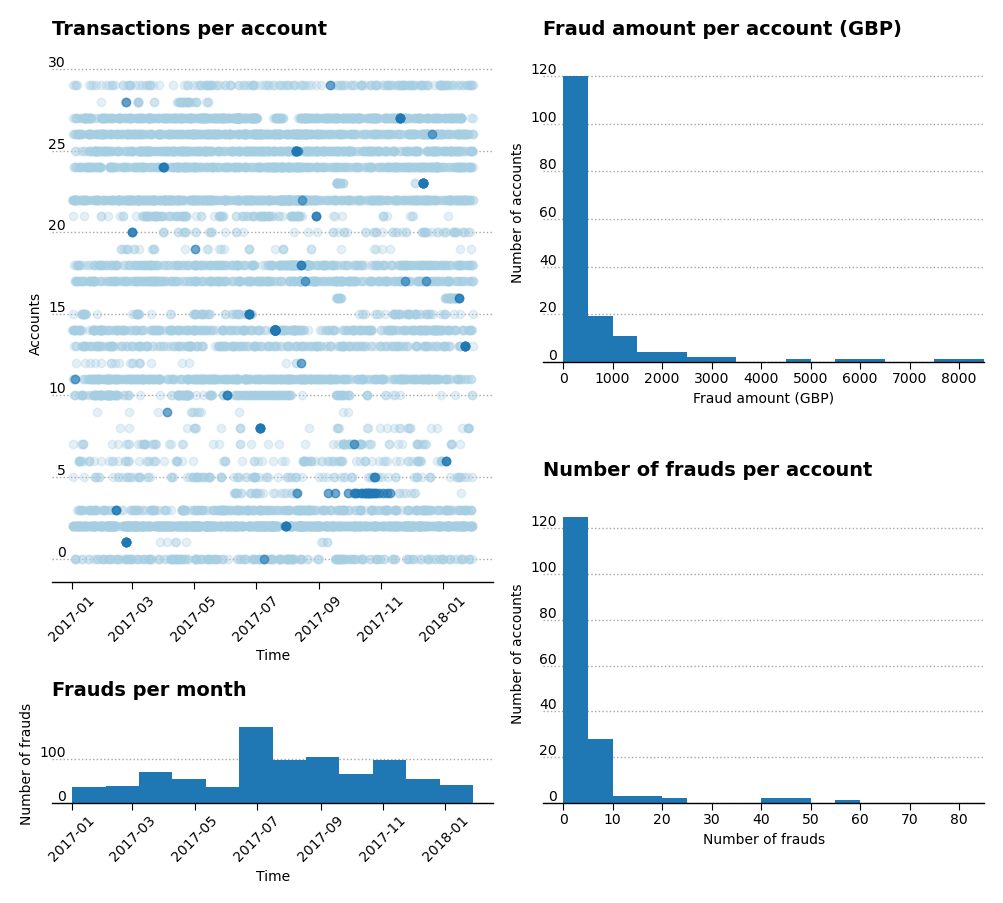

In [82]:
cmap=plt.cm.Paired.colors
fig, axes = plt.subplot_mosaic(
    [['1.', '3.'],
     ['1.', '3.'],
     ['1.', '4.'],
     ['2.', '4.']],
     figsize=(10, 9)
     )


# transactions per account
plt.axes(axes['1.'])
acc_with_frauds = sorted(
    data_df['accountNumber'].loc[data_df['fraudCase'] == 1].unique().tolist()
    )

for i in range(30):
    acc = acc_with_frauds[i]
    fraud = data_df['fraudCase'].loc[data_df['accountNumber'] == acc]
    xx = data_df['transactionTime'].loc[data_df['accountNumber'] == acc]
    plt.scatter(
        xx, np.ones(len(xx))*i, marker='o',
        color=cmap[0], alpha=0.3,
        )
    plt.scatter(
        xx[fraud == 1], np.ones(len(xx[fraud == 1]))*i,
        color=cmap[1], alpha=0.6,
        )

plt.xticks(rotation=45)
plt.xlabel('Time')
plt.ylabel('Accounts')
plt.title('Transactions per account')


# frauds per month
plt.axes(axes['2.'])
plt.hist(
    data_df['transactionTime'].loc[data_df['fraudCase'] == 1],
    bins=12, color=cmap[1]
    )
plt.xlabel('Time')
plt.xticks(rotation=45)
plt.ylabel('Number of frauds')
plt.title('Frauds per month')


# fraud amount per account
plt.axes(axes['3.'])
fraud_df = data_df.loc[data_df.fraudCase == 1]
fraud_amount_per_account = fraud_df.groupby('accountNumber')['transactionAmount'].sum()
plt.hist(fraud_amount_per_account, bins=np.arange(0, 10000, 500))
plt.title('Fraud amount per account (GBP)')
plt.xlabel('Fraud amount (GBP)')
plt.ylabel('Number of accounts')
plt.xlim([-400, 8500])


# number of frauds per account
plt.axes(axes['4.'])
num_frauds_per_account = fraud_df.groupby('accountNumber')['transactionAmount'].count()
plt.hist(num_frauds_per_account, bins=np.arange(0, 100, 5))
plt.title('Number of frauds per account')
plt.xlabel('Number of frauds')
plt.ylabel('Number of accounts')
plt.xlim([-4, 85])


plt.tight_layout()


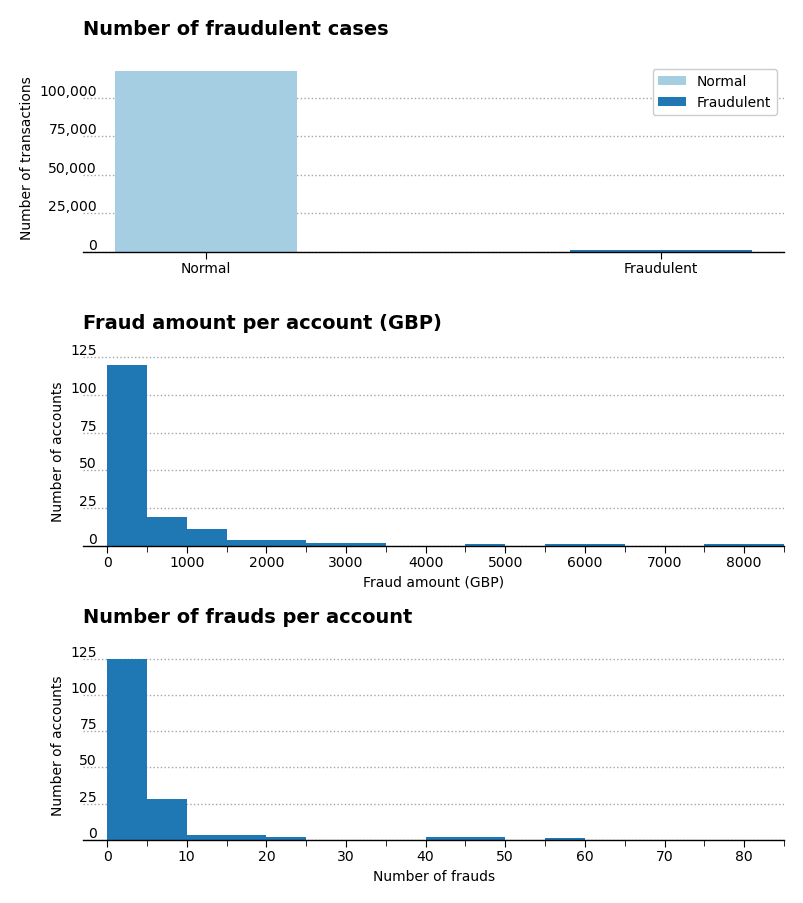

In [73]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 9))

ax1.bar(
    ['Normal', 'Fraudulent'],
    [(data_df.fraudCase == 0).sum(), (data_df.fraudCase == 1).sum()],
    width=0.4, color=plt.cm.Paired.colors, label=['Normal', 'Fraudulent']
    )
ax1.set_xticks([0, 1], ['Normal', 'Fraudulent'])
ax1.set_ylabel('Number of transactions')
ax1.set_title('Number of fraudulent cases')
ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax1.legend(loc='upper right')

ax2.hist(fraud_amount_per_account, bins=np.arange(0, 10000, 500))
ax2.set_title('Fraud amount per account (GBP)')
ax2.set_xlabel('Fraud amount (GBP)')
ax2.set_xlim([-300, 8500])
ax2.set_ylabel('Number of accounts')
ax2.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax2.tick_params(which='minor', length=4, color='k')


ax3.hist(num_frauds_per_account, bins=np.arange(0, 100, 5))
ax3.set_title('Number of frauds per account')
ax3.set_xlabel('Number of frauds')
ax3.set_xlim([-3, 85])
ax3.set_ylabel('Number of accounts')
ax3.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax3.tick_params(which='minor', length=4, color='k')


plt.tight_layout()


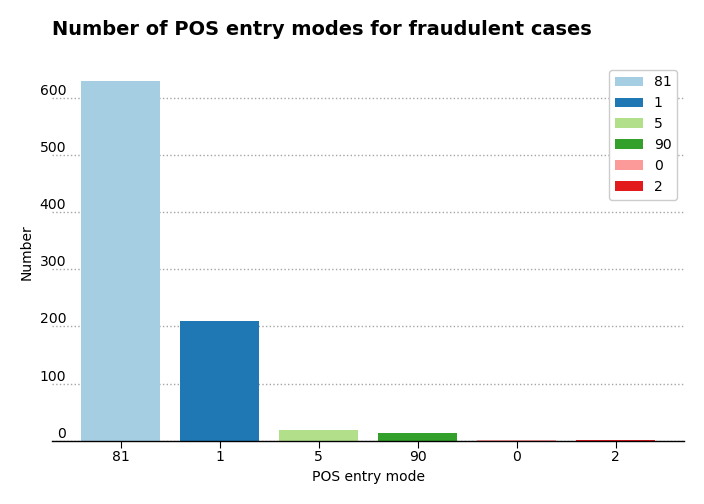

In [34]:
fig, ax = plt.subplots(figsize=(7, 5))
pos_fraud_df = fraud_df.posEntryMode.value_counts(ascending=False)
ax.bar(pos_fraud_df.index, pos_fraud_df.values,
       label=pos_fraud_df.index,
       color=plt.cm.Paired.colors)
ax.set_xlabel('POS entry mode')
ax.set_ylabel('Number')
ax.set_title('Number of POS entry modes for fraudulent cases')
plt.legend()
plt.tight_layout()

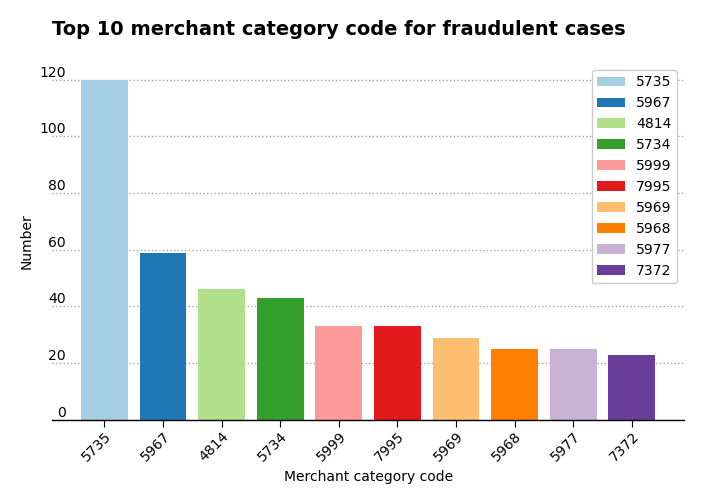

In [35]:
fig, ax = plt.subplots(figsize=(7, 5))
top_num = 10
mcc_fraud_df = fraud_df.mcc.value_counts(ascending=False)[:top_num]
ax.bar(mcc_fraud_df.index, mcc_fraud_df.values,
       label=mcc_fraud_df.index,
       color=plt.cm.Paired.colors)
plt.setp(ax.get_xticklabels(), rotation_mode='anchor', rotation=45, ha='right')
ax.set_xlabel('Merchant category code')
ax.set_ylabel('Number')
ax.set_title(f'Top {top_num} merchant category code for fraudulent cases')
plt.legend()
plt.tight_layout()

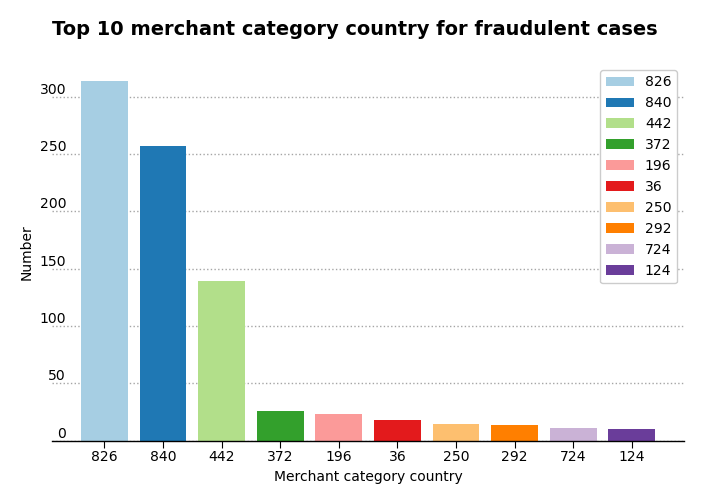

In [36]:
fig, ax = plt.subplots(figsize=(7, 5))
top_num = 10
mctry_fraud_df = fraud_df.merchantCountry.value_counts(ascending=False)[:top_num]
ax.bar(mctry_fraud_df.index, mctry_fraud_df.values,
       label=mctry_fraud_df.index, color=plt.cm.Paired.colors)
ax.set_xlabel('Merchant category country')
ax.set_ylabel('Number')
ax.set_title(f'Top {top_num} merchant category country for fraudulent cases')
plt.legend()
plt.tight_layout()

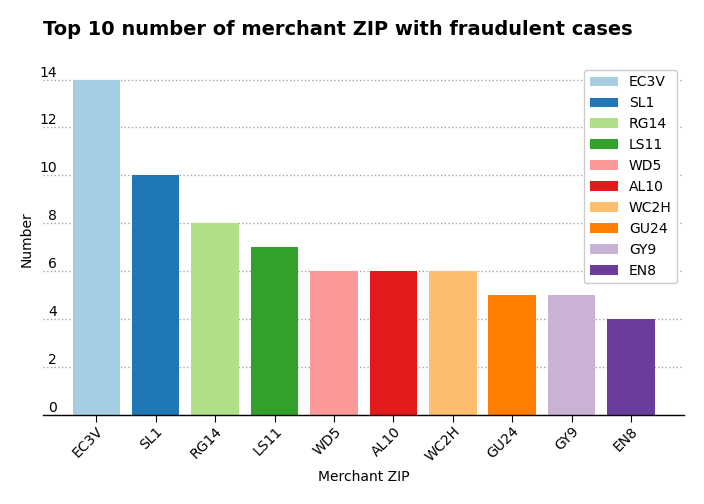

In [37]:
fig, ax = plt.subplots(figsize=(7, 5))
top_num = 10
mod_fraud_df = fraud_df.loc[fraud_df.merchantZip != '0']
mz_fraud_df = mod_fraud_df.merchantZip.value_counts(ascending=False)[:top_num]
ax.bar(mz_fraud_df.index, mz_fraud_df.values, label=mz_fraud_df.index,
       color=plt.cm.Paired.colors)
ax.set_xlabel('Merchant ZIP')
ax.set_ylabel('Number')
ax.set_title(f'Top {top_num} number of merchant ZIP with fraudulent cases')
plt.setp(ax.get_xticklabels(), ha='right',
         rotation_mode='anchor', rotation=45)
plt.legend()
plt.tight_layout()

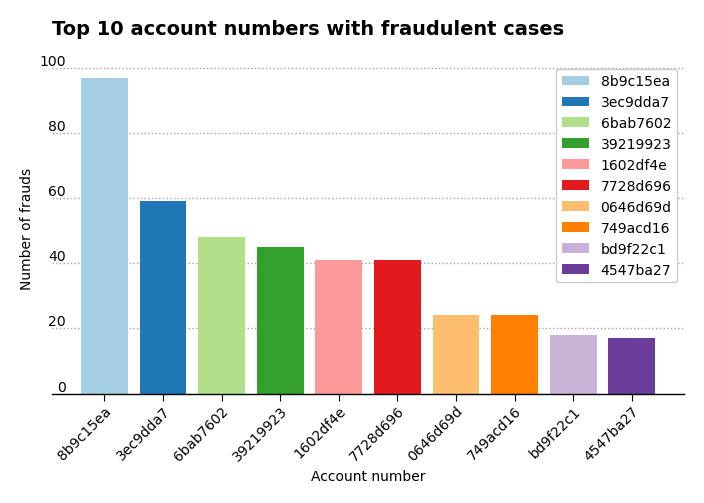

In [38]:
fig, ax = plt.subplots(figsize=(7, 5))
top_num = 10
an_fraud_df = fraud_df.groupby('accountNumber')['accountNumber'].count()
sorted_an_fraud_df = an_fraud_df.nlargest(top_num)
sorted_index = sorted_an_fraud_df.index.astype('str')
ax.bar(sorted_index, sorted_an_fraud_df.values,
       label=sorted_an_fraud_df.index, color=plt.cm.Paired.colors)
ax.set_xlabel('Account number')
ax.set_ylabel('Number of frauds')
ax.set_title(f'Top {top_num} account numbers with fraudulent cases')
plt.setp(ax.get_xticklabels(), ha='right',
         rotation_mode='anchor', rotation=45)
plt.legend()
plt.tight_layout()
